# IMPORTAMOS LIBRERIAS Y DESCARGAMOS CORPUS DE LIBROS

In [1]:
import nltk
nltk.download('book')
from nltk.book import *
import matplotlib.pyplot as plt
import numpy as np

[nltk_data] Downloading collection 'book'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/abc.zip.
[nltk_data]    | Downloading package brown to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/brown.zip.
[nltk_data]    | Downloading package chat80 to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/chat80.zip.
[nltk_data]    | Downloading package cmudict to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/cmudict.zip.
[nltk_data]    | Downloading package conll2000 to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/conll2000.zip.
[nltk_data]    | Downloading package conll2002 to /root/nltk_data...
[nltk_data]    |   Unzipping corpora/conll2002.zip.
[nltk_data]    | Downloading package dependency_treebank to
[nltk_data]    |     /root/nltk_data...
[nltk_data]    |   Unzipping corpora/dependency_treebank.zip.
[nltk_data]    | Downloading package genesis to /root/nltk_data...
[nltk_data]    

*** Introductory Examples for the NLTK Book ***
Loading text1, ..., text9 and sent1, ..., sent9
Type the name of the text or sentence to view it.
Type: 'texts()' or 'sents()' to list the materials.
text1: Moby Dick by Herman Melville 1851
text2: Sense and Sensibility by Jane Austen 1811
text3: The Book of Genesis
text4: Inaugural Address Corpus
text5: Chat Corpus
text6: Monty Python and the Holy Grail
text7: Wall Street Journal
text8: Personals Corpus
text9: The Man Who Was Thursday by G . K . Chesterton 1908


# ANALIZAMOS EL LIBRO TEXT1

In [2]:
text1

<Text: Moby Dick by Herman Melville 1851>

In [3]:
text1.tokens[:10]

['[',
 'Moby',
 'Dick',
 'by',
 'Herman',
 'Melville',
 '1851',
 ']',
 'ETYMOLOGY',
 '.']

In [4]:
len(text1)

260819

## Medida de riqueza lexica en un texto:

Calcular algunas metricas sobre el texto

Cuando tenemos un texto, es normal que algunas palabras se repitan. Queremos definir cuantas palabras unicas se utilizaron respecto al total de palabras del texto. Cuanto mas grande sea nuestra riqueza lexica, mas palabras diferentes utilizo nuestro autor.

$$ R_l = \frac{\text{total de palabras únicas}}{\text{total de palabras}} = \frac{\text{longitud del vocabulario}}{\text{longitud del texto}}$$

Primero realizamos la construcción de un vocabulario (identificamos las palabras unicas que hay en el libro)

Utilizamos la funcion [set()](https://docs.python.org/2/library/sets.html), esta toma la lista de tokens y elimina repetidos, dejando una lista de palabras, con una estructura de datos sort. Para convertirlo a otra estructura usamos **sorted()**. Con esta funcion ordenamos alfabeticamente nuestro set y lo convertimos en lista.

In [5]:
vocabulario = sorted(set(text1))
print(vocabulario[1000:1050])

['Crew', 'Crish', 'Crockett', 'Cross', 'Crossed', 'Crossing', 'Crotch', 'Crowding', 'Crown', 'Crozetts', 'Cruelty', 'Cruising', 'Cruppered', 'Crusaders', 'Crushed', 'Crying', 'Cuba', 'Curious', 'Curse', 'Cursed', 'Curses', 'Cussed', 'Customs', 'Cut', 'Cutter', 'Cutting', 'Cuvier', 'Cyclades', 'Czar', 'D', 'DAGGOO', 'DAM', 'DANCE', 'DANCING', 'DANIEL', 'DANISH', 'DARKENS', 'DARWIN', 'DAVENANT', 'DEAD', 'DEATH', 'DEBELL', 'DECK', 'DEL', 'DESTROYED', 'DEVIL', 'DICTIONARY', 'DID', 'DIGNITY', 'DISCOVERS']


In [6]:
rl = len(vocabulario)/len(text1)
rl

0.07406285585022564

## CREAMOS UNA FUNCIÓN PARA MEDIR LA RIQUEZA LEXICA

In [7]:
def riqueza_lexica(texto):
  vocabulario = sorted(set(texto))
  return len(vocabulario)/len(texto)

riqueza_lexica(text1)

0.07406285585022564

# CREAMOS UNA FUNCIÓN PARA MEDIR EL PORCENTAJE DE UNA PALABRA CON RESPECTO AL CORPUS

In [8]:
def porcentaje_palabra(palabra, texto):
  porcentaje_palabra = 100 * texto.count(palabra)/len(texto)
  return porcentaje_palabra

In [9]:
text1.count('whale')

906

In [10]:
porcentaje_palabra('whale',text1)

0.3473673313677301

## Estadistica del Lenguaje

Los cálculos estadísticos más simples que se pueden efectuar sobre un texto o un corpus son los relacionados con frecuencia de aparición de palabras.

* Podemos construir un diccionario en Python donde las llaves sean las palabras y los valores sean las frecuencias de ocurrencias de esas palabras.

* ejemplo `dic = {'monster': 49 ,  'boat': 54,  ...}`

In [11]:
# Realizar un for básico, computacionalmete es muy pesado si tenemos muchos tokens
dic = {}
for palabra in set(text1):
  dic[palabra] = text1.count(palabra)
dic

{'writer': 2,
 'bound': 28,
 'unreliable': 1,
 'gurglings': 2,
 'buckle': 4,
 'phosphorescence': 1,
 'bakers': 1,
 'tepid': 2,
 'laudanum': 1,
 'amplified': 2,
 'summit': 10,
 'fished': 1,
 'forlornly': 1,
 'rusty': 3,
 'bind': 2,
 'partake': 1,
 'cheapest': 1,
 'bask': 1,
 'cholera': 2,
 'pea': 2,
 'inoffensiveness': 1,
 'unprincipled': 2,
 'hunts': 2,
 'mumbling': 5,
 'omitted': 5,
 'praises': 1,
 'Capting': 4,
 'monster': 49,
 'inscrutably': 1,
 'crescentic': 4,
 'Clinging': 1,
 'moose': 2,
 'babes': 1,
 'disappears': 3,
 'revels': 1,
 'Quitting': 2,
 'precise': 19,
 'wandering': 4,
 'showing': 5,
 'worn': 11,
 'digestive': 1,
 'resident': 1,
 'Bess': 1,
 'casement': 1,
 'Algerine': 1,
 'Byward': 1,
 'besooted': 1,
 'poring': 2,
 'Saw': 1,
 'objections': 2,
 'generations': 6,
 'fashionables': 1,
 'sylphs': 1,
 'properties': 1,
 'peaceful': 6,
 'livers': 3,
 'bloodshed': 1,
 'continued': 14,
 'offing': 4,
 'remaining': 10,
 'nooks': 3,
 'slumbers': 3,
 'Alarmed': 1,
 'Remembering': 1

# DISTRIBUCIONES USANDO FREQDIST DE NLTK

In [12]:
from nltk.book import FreqDist
fdist = FreqDist(text1)
fdist.most_common(10)

[(',', 18713),
 ('the', 13721),
 ('.', 6862),
 ('of', 6536),
 ('and', 6024),
 ('a', 4569),
 ('to', 4542),
 (';', 4072),
 ('in', 3916),
 ('that', 2982)]

<Axes: xlabel='Samples', ylabel='Counts'>

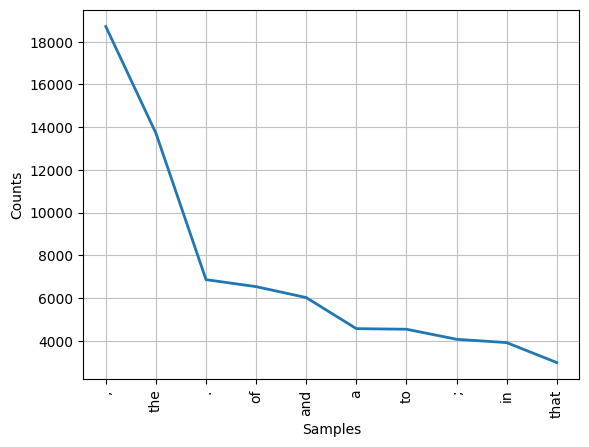

In [13]:
fdist.plot(10)

In [14]:
fdist['whale']

906

# FILTRADO AVANZADOS USANDO STOPWORDS

In [15]:
import nltk
from nltk.corpus import stopwords
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to /root/nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

In [16]:
stop_words = set(stopwords.words('english'))
print(stop_words)

{'these', 'this', 'whom', 'needn', 'before', 'nor', 'wasn', 'above', 'other', 'about', 'ourselves', "it'd", 'same', "haven't", 'over', 'ours', 'both', 'at', 'once', 'further', 'his', "hadn't", 'being', 'him', 'some', 'wouldn', 'y', "shan't", 'off', 'few', 'we', 'them', "she'll", "he'd", 'their', "won't", 'have', 'yourselves', 'shouldn', 'after', 'do', 'has', "hasn't", "we'll", 'when', 'are', 'in', "i've", "they'll", 'who', 'out', 'those', 'just', 'through', "aren't", 'is', 'ain', 'own', 'what', 'only', 'was', 'but', 've', 'there', 'hadn', "it'll", 'myself', 'd', 'on', 's', 'himself', 'can', 'should', 'how', 'isn', 'you', 'why', 'weren', 'aren', 'themselves', 'such', 'hasn', 'me', 'until', 'not', 'than', 'your', "i'd", "we've", "i'm", 'down', "should've", 'she', 'that', 'the', 'below', 'a', 'doing', 'up', 'be', "needn't", 'to', "doesn't", "shouldn't", 'shan', "that'll", "it's", 'and', 'very', 'll', 'between', 'having', 'again', 'here', 'my', "they're", 'mightn', 'didn', 'more', "wouldn'

In [17]:
words = [word.lower() for word in text1 if word.isalpha()]
filtered_words = [word for word in words if word not in stop_words]
print(filtered_words[:10])

['moby', 'dick', 'herman', 'melville', 'etymology', 'supplied', 'late', 'consumptive', 'usher', 'grammar']


In [18]:
fdist_filtered = FreqDist(filtered_words)
fdist_filtered.most_common(10)

[('whale', 1226),
 ('one', 921),
 ('like', 647),
 ('upon', 566),
 ('man', 527),
 ('ship', 518),
 ('ahab', 511),
 ('ye', 472),
 ('sea', 455),
 ('old', 450)]

<Axes: xlabel='Samples', ylabel='Counts'>

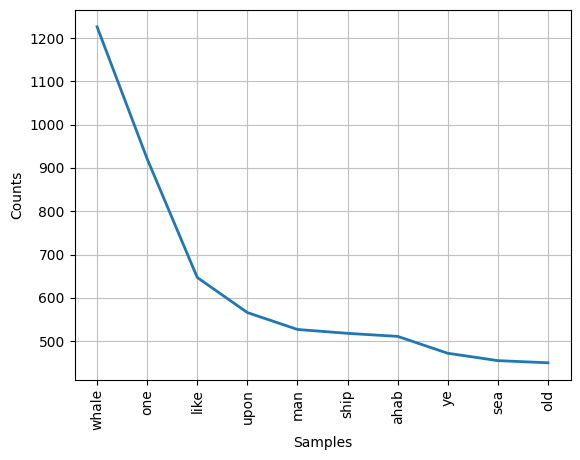

In [19]:
fdist_filtered.plot(10)